In [1]:
from market_maker import MarketMaker, MarketMakerConfig
from order_flow_simulator import OrderFlowSimulator, SimulatorConfig
from orderBook import OrderBook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sim_config = SimulatorConfig(
    initial_price      = 100.0,
    price_vol          = 0.02,
    limit_arrive_prob  = 0.70,
    market_arrive_prob = 0.25,
    cancel_prob        = 0.15,
    seed               = 43,
    informed_fraction  = 0.1
)

spreads = [0.10, 0.15, 0.20, 0.25, 0.30]
skews = [0.001, 0.005, 0.01, 0.05, 0.10]

df = pd.DataFrame(columns=spreads, index=skews)

for skew in skews:
    for spread in spreads:
        book = OrderBook("AAPL")
        sim  = OrderFlowSimulator(book, sim_config)
        mm = MarketMaker(book, MarketMakerConfig(
            base_spread    = spread,
            quote_size     = 5.0,
            inventory_skew = skew,
            max_inventory  = 10.0,
        ))

        N = 3000
        for _ in range(N):
            sim.step()
            mm.step(mark_price=sim._true_price)

        df.loc[skew, spread] = mm._sharpe()
df = df.astype(float)

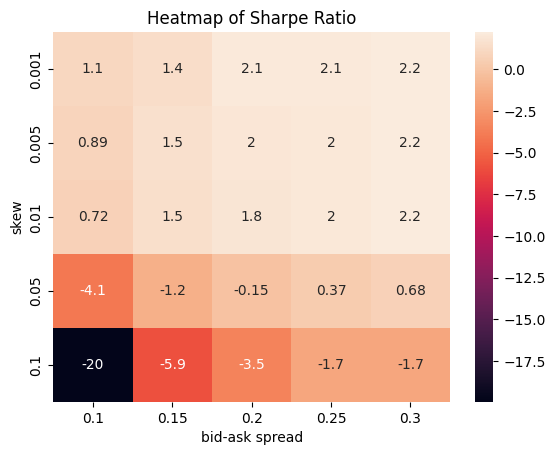

In [7]:
sns.heatmap(df, annot=True)
plt.ylabel("skew")
plt.xlabel("bid-ask spread")
plt.title("Heatmap of Sharpe Ratio")
plt.show()